<a href="https://colab.research.google.com/github/laurenesgarcianatalia-rgb/metodos-/blob/main/M%C3%89TODODELPUNTOFIJO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MÉTODO DE ITERACIÓN DE PUNTO FIJO

## 1. Formulación del Problema
Deseamos encontrar una solución a la ecuación $f(x) = x^3 + 4x^2 - 10 = 0$ en el intervalo $[1, 2]$ mediante el **Método de Iteración de Punto Fijo**, basándonos en el **Algoritmo 2.2** del libro de Análisis Numérico de Burden (página 46).

Un *punto fijo* de una función **g** es un número **p** para el cual $g(p)=p$

Dado un polinomio de buscar una raíz de $f(p)= 0$ podemos definir una función **y** con u  punto fijo en **p** de muchas formas:

### Conversión a la forma $x = g(x)$
Para aplicar este método, debemos reorganizar algebraicamente $f(x) = 0$ de la forma $x = g(x)$. Existen múltiples alternativas de despeje (Ilustración, p. 46):

*   **$g_1(x)$:** $x = x - x^3 - 4x^2 + 10$ *(Diverge)*
*   **$g_2(x)$:** $x = \sqrt{\frac{10}{x} - 4x}$ *(Invalida por raíz negativa)*
*   **$g_3(x)$:** $x = \frac{1}{2}\sqrt{10 - x^3}$ *(Converge)*
*   **$g_4(x)$:** $x = \sqrt{\frac{10}{4 + x}}$ *(Converge rápidamente)*
*   **$g_5(x)$:** $x = x - \frac{x^3 + 4x^2 - 10}{3x^2 + 8x}$ *(Método de Newton-Raphson, muy rápida)*

## 2. Descripción del Algoritmo 2.2 (Método de Iteración del Punto Fijo)
A partir de una aproximación inicial $p_0$, generamos la sucesión $p_n = g(p_{n-1})$ para $n = 1, 2, 3, \dots$. El criterio de parada evaluará la diferencia absoluta entre iteraciones consecutivas:
$$|p_n - p_{n-1}| < TOL$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt #para la gráfica
import pandas as pd #para la tabla


In [2]:
# 1. definiendo la ecuación del ejemplo
def f(x):
  return x**3 + 4*x**2 - 10.0

In [3]:
# Despejes g(x) indicados en el libro (Tabla 2.2) y realizados en clase
def g1(x): return x - x**3 - 4*x**2 + 10.0
def g2(x): return np.sqrt(10.0/x - 4*x)
def g3(x): return 0.5 * np.sqrt(10.0 - x**3)
def g4(x): return np.sqrt(10.0 / (4.0 + x))
def g5(x): return x - (x**3 + 4*x**2 - 10.0) / (3*x**2 + 8*x)

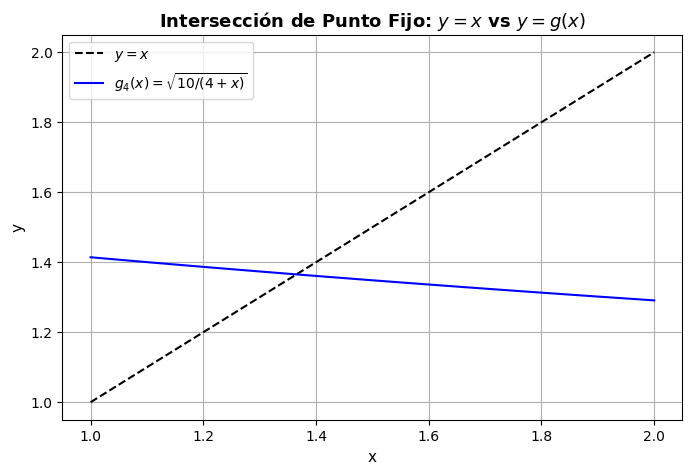

In [4]:
# 2 Análisis gráfico

# Visualización gráfica de y = x frente a y = g4(x)
x_vals = np.linspace(1.0, 2.0, 100)
plt.figure(figsize=(8, 5))

plt.plot(x_vals, x_vals, 'k--', label='$y = x$')
plt.plot(x_vals, g4(x_vals), 'b-', label='$g_4(x) = \\sqrt{10/(4+x)}$')

plt.title('Intersección de Punto Fijo: $y = x$ vs $y = g(x)$', fontsize=13, fontweight='bold')
plt.xlabel('x', fontsize=11)
plt.ylabel('y', fontsize=11)
plt.legend()
plt.grid(True)
plt.show()


## 3. Implementación del Algoritmo 2.2
A continuación se programa la función que sigue estrictamente los **Pasos 1 al 7** del método de punto fijo.

In [10]:
def algoritmo_punto_fijo(g, p0, tol, max):
    """
    ENTRADA:
        g: función de iteración g(x)
        p0: aproximación inicial
        tol: tolerancia deseada (TOL)
        max: número máximo de iteraciones (N0)
    SALIDA:
        p: solución aproximada
        df: tabla con los registros de cada iteración
        mensaje: estado final del procedimiento
    """
    registros = []

    # Paso 1: Inicializar i = 1
    i = 1

    # Guardar valor inicial p0 (iteración 0)
    registros.append([0, p0, None, abs(f(p0))])

    # Paso 2: Ciclo iterativo (Mientras i <= N0)
    while i <= max:
        # Paso 3: Determine p = g(p0) (Calcule p_n)
        try:
            p = g(p0)
        except (ValueError, ZeroDivisionError):
            df = pd.DataFrame(registros, columns=['n', 'p_n', 'Error (|p_n - p_{n-1}|)', '|f(p_n)|'])
            return None, df, f"El método falló en la iteración {i}: Operación matemática inválida."

        # Calculamos el error absoluto con la aproximación anterior
        error = abs(p - p0)

        # Guardamos en la tabla
        registros.append([i, p, error, abs(f(p))])

        # Paso 4: Si |p - p0| < TOL entonces ÉXITO
        if error < tol:
            df = pd.DataFrame(registros, columns=['n', 'p_n', 'Error (|p_n - p_{n-1}|)', '|f(p_n)|'])
            mensaje = f"Procedimiento completado exitosamente en {i} iteraciones."
            return p, df, mensaje

        # Paso 5: Incrementamos i = i + 1
        i += 1

        # Paso 6: Actualizar p0 = p
        p0 = p

    # Paso 7: Criterio de falla
    df = pd.DataFrame(registros, columns=['n', 'p_n', 'Error (|p_n - p_{n-1}|)', '|f(p_n)|'])
    mensaje = f"El método falló después de N0 = {max} iteraciones."
    return p, df, mensaje

## 4. Ejecución y Resultados
Ejecutamos el algoritmo utilizando el punto inicial $p_0 = 1.5$, una tolerancia de $TOL = 10^{-4}$ ($0.0001$) y $N_0 = 50$ iteraciones máximas. Probaremos la función con el despeje convergente $g_5(x)$ (el mismo que se evaluo en clase) ya que es el que converge más rápido.

In [11]:
# Parámetros iniciales
p0_inicial = 1.5
tolerancia = 0.0001
iteraciones_maximas = 50

# Ejecutamos el punto fijo usando g5(x)
raiz_aprox, tabla_resultados, estado = algoritmo_punto_fijo(
    g5, p0_inicial, tolerancia, iteraciones_maximas
)

print("TABLA DE ITERACIONES (PUNTO FIJO - g4):")
display(tabla_resultados)

print(" RESULTADO FINAL DEL MÉTODO DE PUNTO FIJO")

print(f"Estado: {estado}")
if raiz_aprox is not None:
    print(f"La raíz aproximada final es: p = {raiz_aprox:.8f}")
    print(f"Evaluación en la función original: f(p) = {f(raiz_aprox):.8e}")


TABLA DE ITERACIONES (PUNTO FIJO - g4):


,n,p_n,Error (|p_n - p_{n-1}|),|f(p_n)|
0,0,1.500000,NaN,2.375000e+00
1,1,1.373333,0.126667,1.343455e-01
2,2,1.365262,0.008071,5.284612e-04
3,3,1.365230,0.000032,8.290549e-09


 RESULTADO FINAL DEL MÉTODO DE PUNTO FIJO
Estado: Procedimiento completado exitosamente en 3 iteraciones.
La raíz aproximada final es: p = 1.36523001
Evaluación en la función original: f(p) = 8.29054869e-09


Antes de probar con el $g_5$ probamos con otras funciones que por la tolerancia de error del código les faltaban varias iteraciones para llegar a la raíz. Entonces tal como en clase, debemos saber elegir la funcion $g(x)$